# Лабораторна 2. Від сирих даних до нейромережі

Перегуда Владислав Анатолійович

### Налаштування
Бібліотеки встановлюються лише за відсутності потрібної версії. Обчислення виконую на CPU з одним потоком.

In [1]:
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError

requirements = {
    "torch": "2.8.0", "numpy": "2.2.6", "pandas": "2.2.3",
    "scikit-learn": "1.7.2", "matplotlib": "3.10.7",
    "tensorboard": "2.20.0", "gradio": "5.49.1", "requests": "2.32.5",
    "ipywidgets": "8.1.7"
}
install = []
for package, wanted in requirements.items():
    try:
        installed = version(package).split("+")[0]
    except PackageNotFoundError:
        installed = None
    if installed != wanted:
        install.append(f"{package}=={wanted}")
if install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *install])
print("Бібліотеки готові")

Бібліотеки готові


In [2]:
import random
import hashlib
from pathlib import Path
from io import BytesIO
import copy
import numpy as np
import pandas as pd
import requests
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.tensorboard import SummaryWriter
from IPython.display import display, Markdown, IFrame

SEED = 42
def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

set_seed()
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
device = torch.device("cpu")
LAB_DIR = Path("lab2") if Path("lab2").is_dir() else Path(".")
MODELS_DIR = LAB_DIR / "models"
RUNS_DIR = LAB_DIR / "runs"
MODELS_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)
get_ipython().run_line_magic("matplotlib", "inline")
print("Seed:", SEED, "Пристрій:", device)
print("PyTorch:", torch.__version__)

Seed: 42 Пристрій: cpu
PyTorch: 2.8.0+cpu


## 0. Опрацювання демо-ноутбука

Довідник: [демо лекції 3-4](https://fantkolja.github.io/ai-systems-lectures/lectures/03-nn/nn_demo.ipynb).

### 0.1 Мої відповіді

1. kNN враховує зв'язок пропущеної ознаки з іншими числовими ознаками. Значення оцінюється за схожими спостереженнями, а рядок залишається у вибірці. Моделі імпутації потрібно навчати лише на train.

2. MSE є функцією втрат, тому її зручно порівнювати на train і val під час навчання. RMSE, MAE та R² після навчання показують похибку в одиницях цілі та якість відносно простого прогнозу. В експерименті нижче MSE сильніше реагує на рідкісні великі похибки, а MAE менше зміщує лінію через них.

3. Найбільша вага після 2.6 у MedInc: 0.8281, тобто більший дохід пов'язаний з більшим прогнозом ціни. diag_coord має вагу -0.3032, а bedperroom 0.1968, тому додані ознаки також використовуються моделлю. Це зміни за незмінних інших ознак, а не доказ причинного впливу.

4. Простий baseline для регресії завжди прогнозує середнє значення цілі на train. Його метрики показують, чи навчена модель краща за постійну відповідь. Для нейромережі основним baseline є навчена лінійна регресія.

5. ReLU обнуляє від'ємні значення, а Leaky ReLU залишає для них малий нахил. Sigmoid дає значення від 0 до 1, Tanh від -1 до 1. Нижче всі чотири функції з демо застосовані до тих самих 1000 випадкових X.

6. Після обробки у демо залишаються 7 ознак, а архітектура має розміри 7 → 64 → 32 → 1. Параметри шарів: 7 × 64 + 64 = 512, 64 × 32 + 32 = 2080, 32 × 1 + 1 = 33, разом 2625. ReLU не має навчених параметрів.

7. 200 епох у 3.5 ще не виглядають оптимальною межею: val MSE зменшилась з 0.3738 на епосі 190 до 0.3711 на епосі 199. Наприкінці обидві криві ще знижуються, тому варто перевірити довше навчання. У своїх моделях зберігаю стан з найменшою val MSE та окремо порівнюю кількість епох.

### 0.2 Експеримент з функцією втрат
Порівнюю MSE і MAE на однаковій лінійній залежності з шумом та кількома великими похибками в train. Початкові ваги, дані, оптимізатор і кількість епох однакові.

In [3]:
set_seed()
x_exp = torch.linspace(-2, 2, 120).reshape(-1, 1)
y_exp = 3 * x_exp + 2 + 0.2 * torch.randn_like(x_exp)
x_exp_train, x_exp_val = x_exp[:90], x_exp[90:]
y_exp_train = y_exp[:90].clone()
y_exp_val = y_exp[90:]
y_exp_train[[10, 40, 70]] += 12
loss_results = []
for loss_name, loss_fn in [("MSE", nn.MSELoss()), ("MAE", nn.L1Loss())]:
    set_seed()
    exp_model = nn.Linear(1, 1)
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=0.03)
    for epoch in range(600):
        exp_optimizer.zero_grad()
        loss = loss_fn(exp_model(x_exp_train), y_exp_train)
        loss.backward()
        exp_optimizer.step()
    with torch.no_grad():
        exp_pred = exp_model(x_exp_val).numpy().ravel()
    exp_true = y_exp_val.numpy().ravel()
    loss_results.append({"Функція втрат": loss_name,
                         "w": exp_model.weight.item(), "b": exp_model.bias.item(),
                         "val MSE": mean_squared_error(exp_true, exp_pred),
                         "val MAE": mean_absolute_error(exp_true, exp_pred)})
loss_results = pd.DataFrame(loss_results)
display(loss_results.round(4))
display(Markdown(f"На val MSE-навчання дало MAE {loss_results.loc[0, 'val MAE']:.4f}, "
                 f"а MAE-навчання {loss_results.loc[1, 'val MAE']:.4f}. "
                 "Це приклад з викидами, тому результат не означає перевагу MAE на всіх даних."))

,Функція втрат,w,b,val MSE,val MAE
0,MSE,2.9162,2.3702,0.0887,0.2406
1,MAE,3.0024,2.0062,0.0293,0.1410


На val MSE-навчання дало MAE 0.2406, а MAE-навчання 0.1410. Це приклад з викидами, тому результат не означає перевагу MAE на всіх даних.

### 0.3 Функції активації та кількість параметрів

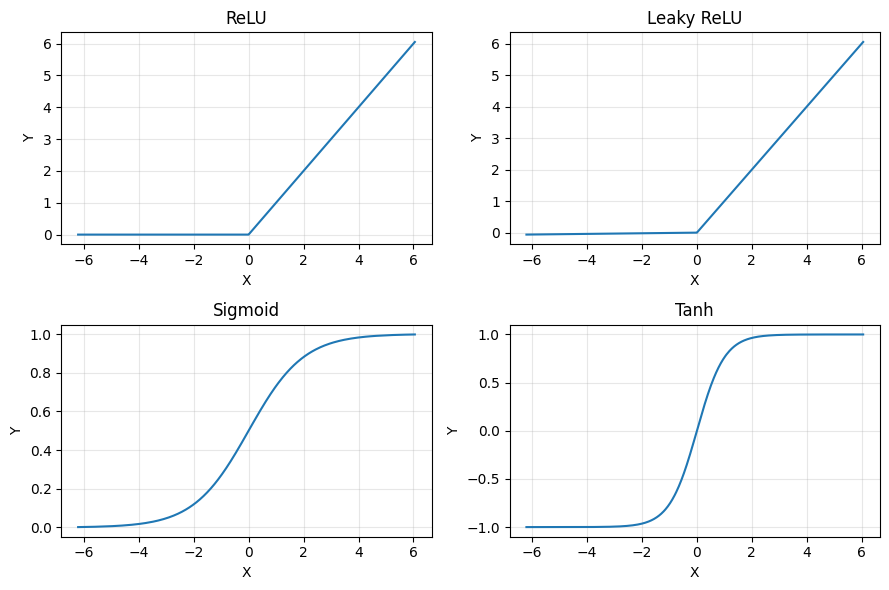

7 × 64 + 64 = 512
64 × 32 + 32 = 2080
32 × 1 + 1 = 33
Разом: 2625


In [4]:
set_seed()
x_activation = torch.sort(torch.randn(1000) * 2).values
activations = {"ReLU": nn.ReLU(), "Leaky ReLU": nn.LeakyReLU(0.01),
               "Sigmoid": nn.Sigmoid(), "Tanh": nn.Tanh()}
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, (name, activation) in zip(axes.ravel(), activations.items()):
    ax.plot(x_activation.numpy(), activation(x_activation).numpy())
    ax.set(title=name, xlabel="X", ylabel="Y")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

demo_sizes = [7, 64, 32, 1]
parameter_counts = [a * b + b for a, b in zip(demo_sizes[:-1], demo_sizes[1:])]
for a, b, count in zip(demo_sizes[:-1], demo_sizes[1:], parameter_counts):
    print(f"{a} × {b} + {b} = {count}")
print("Разом:", sum(parameter_counts))

## 1. Датасет

Визначаю номер через SHA-256 від ПІБ у заданому форматі.

In [5]:
DATASETS = [
    "King County House Sales", "Diamonds", "Concrete Compressive Strength",
    "Auto MPG", "Wine Quality", "Laptop Price", "Bike Sharing Demand",
    "Ames House Prices", "Medical Insurance Cost", "Abalone"
]
FULL_NAME = "Перегуда Владислав Анатолійович"
dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print("ПІБ:", FULL_NAME)
print("Індекс:", dataset_index)
print(f"Датасет №{dataset_index + 1}:", DATASETS[dataset_index])
assert DATASETS[dataset_index] == "Abalone"

ПІБ: Перегуда Владислав Анатолійович
Індекс: 9
Датасет №10: Abalone


## 2.1 Підготовка даних

Завантажую регресійний файл [mstz/abalone](https://huggingface.co/datasets/mstz/abalone), а не його бінарну версію. Ціль number_of_rings є кількістю кілець, яку прогнозую як число.

Одразу ділю дані на train, val і test у пропорції 70/15/15. Аналізую лише train, щоб статистики й рішення про ознаки не використовували інформацію з val або test. Це запобігає data leakage.

In [6]:
DATA_URL = "https://huggingface.co/datasets/mstz/abalone/resolve/3f7aee9ca247e7b491a84390817e1934f270fdc7/abalone/train.csv"
response = requests.get(DATA_URL, timeout=90)
response.raise_for_status()
df = pd.read_csv(BytesIO(response.content))
train_df, remaining_df = train_test_split(df, test_size=0.3, random_state=SEED)
val_df, test_df = train_test_split(remaining_df, test_size=0.5, random_state=SEED)
assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("Ціль: number_of_rings")

train/val/test: 2923 627 627
Ціль: number_of_rings


In [7]:
display(train_df.head())
train_df.info()
display(train_df.describe().round(3))
print("Пропуски на train:")
display(train_df.isna().sum().to_frame("Кількість"))
print("Дублікати на train:", train_df.duplicated().sum())

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
2830,F,0.525,0.430,0.135,0.8435,0.4325,0.1800,0.1815,9
925,I,0.430,0.325,0.100,0.3645,0.1575,0.0825,0.1050,7
3845,M,0.455,0.350,0.105,0.4160,0.1625,0.0970,0.1450,11
547,M,0.205,0.155,0.045,0.0425,0.0170,0.0055,0.0155,7
2259,F,0.590,0.465,0.160,1.1005,0.5060,0.2525,0.2950,13


<class 'pandas.core.frame.DataFrame'>
Index: 2923 entries, 2830 to 860
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              2923 non-null   object 
 1   length           2923 non-null   float64
 2   diameter         2923 non-null   float64
 3   height           2923 non-null   float64
 4   whole_weight     2923 non-null   float64
 5   shucked_weight   2923 non-null   float64
 6   viscera_weight   2923 non-null   float64
 7   shell_weight     2923 non-null   float64
 8   number_of_rings  2923 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 228.4+ KB


,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,number_of_rings
count,2923.000,2923.000,2923.000,2923.000,2923.000,2923.000,2923.000,2923.000
mean,0.526,0.410,0.140,0.836,0.363,0.182,0.241,9.984
std,0.120,0.099,0.042,0.492,0.224,0.109,0.141,3.239
min,0.075,0.055,0.000,0.002,0.001,0.000,0.002,1.000
25%,0.450,0.350,0.115,0.444,0.187,0.094,0.130,8.000
50%,0.545,0.425,0.145,0.808,0.340,0.173,0.235,10.000
75%,0.615,0.485,0.165,1.160,0.508,0.256,0.330,11.000
max,0.815,0.650,1.130,2.826,1.488,0.760,1.005,29.000


Пропуски на train:


,Кількість
sex,0
length,0
diameter,0
height,0
whole_weight,0
shucked_weight,0
viscera_weight,0
shell_weight,0
number_of_rings,0


Дублікати на train: 0


У train пропусків немає, тому імпутацію пропусків не застосовую. Пізніше окремо перевіряю фізично підозрілі значення height.

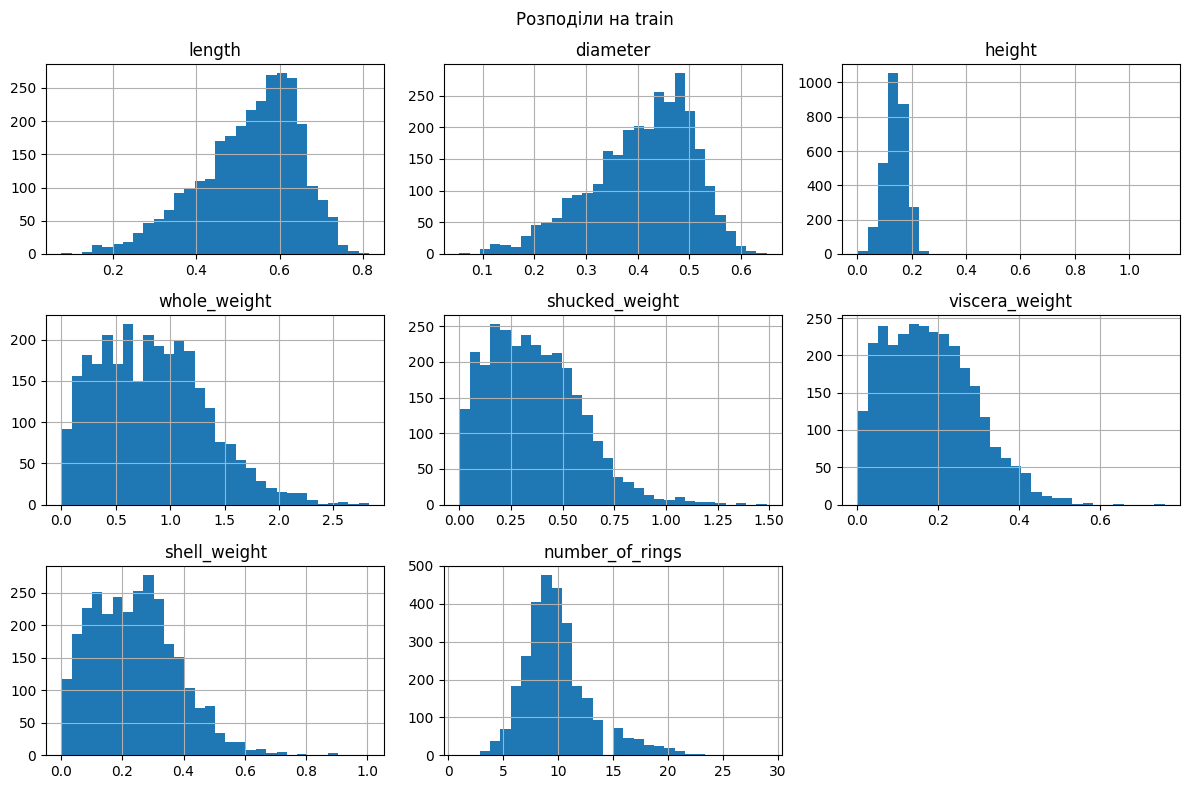

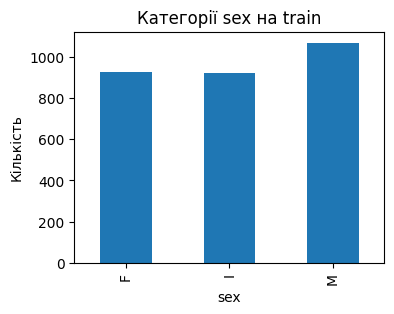

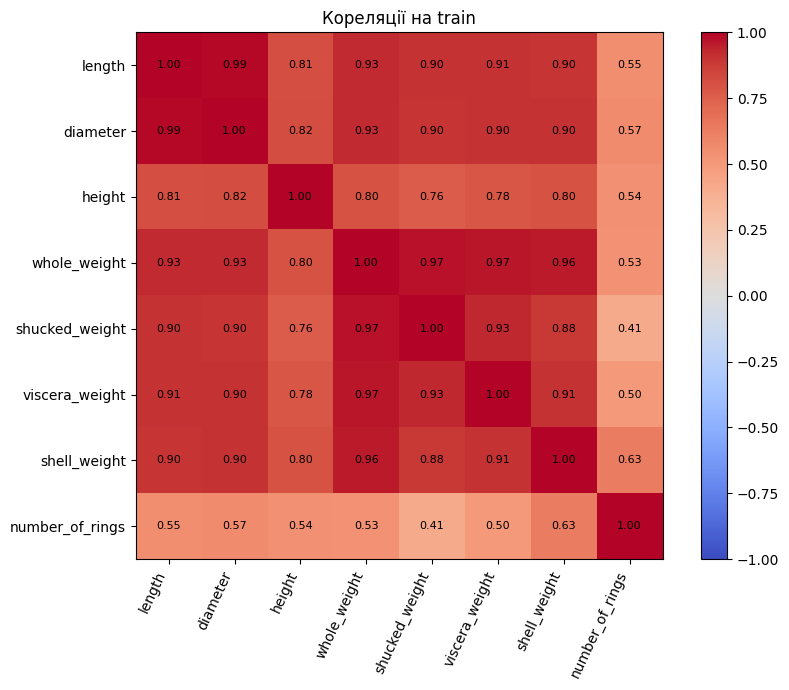

Кореляція length та diameter: 0.9872


,Асиметрія
length,-0.636
diameter,-0.606
height,4.107
whole_weight,0.521
shucked_weight,0.724
viscera_weight,0.552
shell_weight,0.641
number_of_rings,1.130


number_of_rings
24    2
25    1
26    1
27    2
29    1
Name: count, dtype: int64

In [8]:
train_df.hist(bins=30, figsize=(12, 8))
plt.suptitle("Розподіли на train")
plt.tight_layout()
plt.show()
train_df["sex"].value_counts().sort_index().plot.bar(figsize=(4, 3))
plt.title("Категорії sex на train")
plt.ylabel("Кількість")
plt.show()

corr = train_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr)), corr.columns, rotation=65, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax)
ax.set_title("Кореляції на train")
plt.tight_layout()
plt.show()
print("Кореляція length та diameter:", round(corr.loc["length", "diameter"], 4))
display(train_df.select_dtypes("number").skew().round(3).to_frame("Асиметрія"))
display(train_df["number_of_rings"].value_counts().sort_index().tail())

Маси й number_of_rings мають правий хвіст. Явного піка через обрізання на максимальному значенні не видно. length і diameter майже дублюють один одного, тому diameter прибираю. Маси різних частин залишаю: вони пов'язані, але описують різні складові молюска.

Великі маси та рідкісні великі значення цілі не видаляю тільки через віддаленість від середнього. Нульова height або height більша за length є підозрілим вимірюванням. Такі значення замінюю медіаною коректної height з train, однаково для всіх вибірок, без видалення рядків val і test.

Категорію sex кодую двома індикаторами, F є базовою категорією. Інших штучних ознак не додаю.

In [9]:
invalid_height = (train_df["height"] <= 0) | (train_df["height"] > train_df["length"])
display(train_df.loc[invalid_height, ["length", "height", "number_of_rings"]])
height_median = float(train_df.loc[~invalid_height, "height"].median())
numeric_cols = ["length", "height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight"]
sex_categories = sorted(train_df["sex"].unique().tolist())

def prepare_features(frame, median=height_median):
    numeric = frame[numeric_cols].copy()
    invalid = (numeric["height"] <= 0) | (numeric["height"] > numeric["length"])
    numeric.loc[invalid, "height"] = median
    sex = pd.Categorical(frame["sex"], categories=sex_categories)
    encoded = pd.get_dummies(sex, prefix="sex", drop_first=True, dtype=float)
    encoded.index = frame.index
    return pd.concat([numeric, encoded], axis=1)

features_train = prepare_features(train_df)
features_val = prepare_features(val_df)
features_test = prepare_features(test_df)
feature_cols = features_train.columns.tolist()
print("Підозрілі height на train:", int(invalid_height.sum()))
print("Медіана коректної height на train:", height_median)
print("Ознаки:", feature_cols)
print("Кількість входів:", len(feature_cols))

,length,height,number_of_rings
2051,0.455,1.13,8
3996,0.315,0.00,6
1257,0.430,0.00,8


Підозрілі height на train: 3
Медіана коректної height на train: 0.145
Ознаки: ['length', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'sex_I', 'sex_M']
Кількість входів: 8


## 2.2 Лінійна регресія

StandardScaler навчаю лише на train. Також стандартизую ціль за train для стабільного навчання, але всі метрики й прогнози повертаю в кількість кілець. Стан моделі вибираю за найменшою val MSE.

In [10]:
scaler = StandardScaler().fit(features_train)
X_train = scaler.transform(features_train).astype(np.float32)
X_val = scaler.transform(features_val).astype(np.float32)
X_test = scaler.transform(features_test).astype(np.float32)
y_train = train_df["number_of_rings"].to_numpy(dtype=np.float64)
y_val = val_df["number_of_rings"].to_numpy(dtype=np.float64)
y_test = test_df["number_of_rings"].to_numpy(dtype=np.float64)
y_mean, y_scale = float(y_train.mean()), float(y_train.std())
x_train_t = torch.tensor(X_train)
x_val_t = torch.tensor(X_val)
x_test_t = torch.tensor(X_test)
y_train_t = torch.tensor((y_train - y_mean) / y_scale, dtype=torch.float32).reshape(-1, 1)
y_val_t = torch.tensor((y_val - y_mean) / y_scale, dtype=torch.float32).reshape(-1, 1)
print("Середні стандартизованих ознак train:", X_train.mean(axis=0).round(5))
print("Розміри тензорів:", x_train_t.shape, x_val_t.shape, x_test_t.shape)

Середні стандартизованих ознак train: [ 0.  0.  0.  0.  0.  0. -0. -0.]
Розміри тензорів: torch.Size([2923, 8]) torch.Size([627, 8]) torch.Size([627, 8])


In [11]:
def make_model(hidden, n_inputs):
    if not hidden:
        return nn.Linear(n_inputs, 1)
    layers = []
    for width in hidden:
        layers.extend([nn.Linear(n_inputs, width), nn.ReLU()])
        n_inputs = width
    layers.append(nn.Linear(n_inputs, 1))
    return nn.Sequential(*layers)

models = {}
histories = {}
configs = {}
validation_scores = {}
best_epochs = {}

def train_variant(name, hidden, lr, epochs, batch_size):
    set_seed()
    model = make_model(hidden, len(feature_cols))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    run_dir = RUNS_DIR / name
    run_dir.mkdir(exist_ok=True)
    for old_log in run_dir.glob("events.out.tfevents.*"):
        old_log.unlink()
    writer = SummaryWriter(str(run_dir))
    history = {"train": [], "val": []}
    best_loss = float("inf")
    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(len(x_train_t))
        for batch in order.split(batch_size):
            optimizer.zero_grad()
            loss = loss_fn(model(x_train_t[batch]), y_train_t[batch])
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_mse = loss_fn(model(x_train_t), y_train_t).item() * y_scale ** 2
            val_mse = loss_fn(model(x_val_t), y_val_t).item() * y_scale ** 2
        history["train"].append(train_mse)
        history["val"].append(val_mse)
        writer.add_scalar("MSE/train", train_mse, epoch)
        writer.add_scalar("MSE/val", val_mse, epoch)
        if val_mse < best_loss:
            best_loss = val_mse
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
    writer.close()
    model.load_state_dict(best_state)
    model.eval()
    config = {"hidden": list(hidden), "lr": lr, "epochs": epochs, "batch_size": batch_size}
    checkpoint = {"state_dict": best_state, "config": config, "features": feature_cols,
                  "numeric_cols": numeric_cols, "sex_categories": sex_categories,
                  "height_median": height_median, "x_mean": scaler.mean_.tolist(),
                  "x_scale": scaler.scale_.tolist(), "y_mean": y_mean, "y_scale": y_scale,
                  "best_epoch": best_epoch, "full_name": FULL_NAME, "target": "number_of_rings"}
    torch.save(checkpoint, MODELS_DIR / f"{name}.pt")
    models[name], histories[name], configs[name] = model, history, config
    validation_scores[name], best_epochs[name] = best_loss, best_epoch
    print(f"{name}: val MSE={best_loss:.4f}, найкраща епоха={best_epoch}/{epochs}")

def metrics(y_true, predictions):
    mse = float(mean_squared_error(y_true, predictions))
    return {"MSE": mse, "RMSE": mse ** 0.5,
            "MAE": float(mean_absolute_error(y_true, predictions)),
            "R2": float(r2_score(y_true, predictions))}

train_variant("linear", [], lr=0.03, epochs=1000, batch_size=len(x_train_t))

linear: val MSE=4.9750, найкраща епоха=328/1000


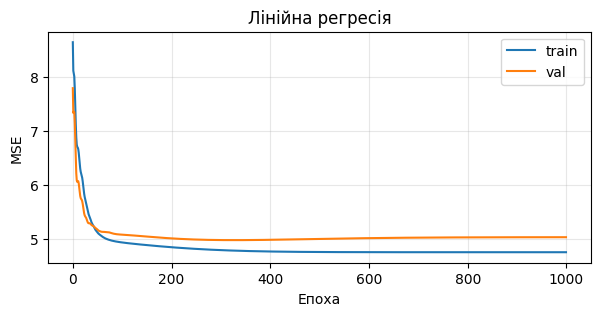

,MSE,RMSE,MAE,R2
Середнє train,10.2727,3.2051,2.3522,-0.0008
Лінійна регресія,4.7316,2.1752,1.5663,0.5390


In [12]:
plt.figure(figsize=(7, 3))
plt.plot(histories["linear"]["train"], label="train")
plt.plot(histories["linear"]["val"], label="val")
plt.xlabel("Епоха")
plt.ylabel("MSE")
plt.title("Лінійна регресія")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
with torch.no_grad():
    linear_predictions = models["linear"](x_test_t).numpy().ravel() * y_scale + y_mean
linear_metrics = metrics(y_test, linear_predictions)
mean_metrics = metrics(y_test, np.full(len(y_test), y_mean))
display(pd.DataFrame([mean_metrics, linear_metrics], index=["Середнє train", "Лінійна регресія"]).round(4))

In [13]:
weights = models["linear"].weight.detach().numpy().ravel() * y_scale
weight_table = pd.DataFrame({"Ознака": feature_cols, "Кілець на 1 std": weights,
                             "Вага в початковому масштабі": weights / scaler.scale_})
weight_table = weight_table.iloc[np.argsort(-np.abs(weights))]
display(weight_table.round(4))
positive = weight_table.loc[weight_table["Кілець на 1 std"].idxmax()]
negative = weight_table.loc[weight_table["Кілець на 1 std"].idxmin()]
display(Markdown(f"Найбільша додатна вага у {positive['Ознака']}: {positive['Кілець на 1 std']:.4f} кілець на 1 std. "
                 f"Найбільша від'ємна у {negative['Ознака']}: {negative['Кілець на 1 std']:.4f}. "
                 "Це зміни за незмінних інших ознак, а не причинний вплив. "
                 "Через кореляцію мас окремі ваги треба тлумачити обережно."))

,Ознака,Кілець на 1 std,Вага в початковому масштабі
3,shucked_weight,-3.8617,-17.2791
2,whole_weight,2.9786,6.0541
5,shell_weight,1.6525,11.7586
1,height,1.0587,27.7476
4,viscera_weight,-0.8554,-7.8329
0,length,0.6394,5.3417
6,sex_I,-0.3471,-0.7467
7,sex_M,0.0332,0.0689


Найбільша додатна вага у whole_weight: 2.9786 кілець на 1 std. Найбільша від'ємна у shucked_weight: -3.8617. Це зміни за незмінних інших ознак, а не причинний вплив. Через кореляцію мас окремі ваги треба тлумачити обережно.

## 2.3 Дві архітектури нейромережі

nn_v1 має один прихований шар із 32 нейронами. nn_v2 має два приховані шари, 64 і 32 нейрони. Для обох використовую ReLU, Adam, lr 0.001, 200 епох і batch 128.

In [14]:
train_variant("nn_v1", [32], lr=0.001, epochs=200, batch_size=128)
train_variant("nn_v2", [64, 32], lr=0.001, epochs=200, batch_size=128)
architecture_table = pd.DataFrame([
    {"Модель": name, "Архітектура": str(configs[name]["hidden"]),
     "Параметри": sum(p.numel() for p in models[name].parameters()),
     "val MSE": validation_scores[name]}
    for name in ["linear", "nn_v1", "nn_v2"]
])
display(architecture_table.round(4))

nn_v1: val MSE=4.6513, найкраща епоха=148/200


nn_v2: val MSE=4.5301, найкраща епоха=66/200


,Модель,Архітектура,Параметри,val MSE
0,linear,[],9,4.9750
1,nn_v1,[32],321,4.6513
2,nn_v2,"[64, 32]",2689,4.5301


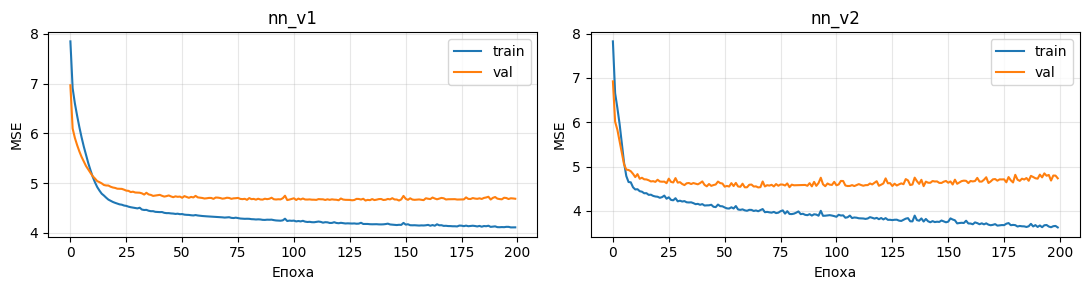

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, name in zip(axes, ["nn_v1", "nn_v2"]):
    ax.plot(histories[name]["train"], label="train")
    ax.plot(histories[name]["val"], label="val")
    ax.set(title=name, xlabel="Епоха", ylabel="MSE")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.4 Підбір гіперпараметрів

Беру архітектуру з меншою val MSE. Кожну зміну порівнюю з її початковим варіантом: тільки lr 0.003, тільки 400 епох або тільки batch 64. Для кожного запуску початковий seed той самий, test не використовую для вибору.

In [16]:
best_architecture = min(["nn_v1", "nn_v2"], key=validation_scores.get)
hidden = configs[best_architecture]["hidden"]
print("Обрана архітектура:", best_architecture)
train_variant(f"{best_architecture}_lr003", hidden, lr=0.003, epochs=200, batch_size=128)
train_variant(f"{best_architecture}_epochs400", hidden, lr=0.001, epochs=400, batch_size=128)
train_variant(f"{best_architecture}_batch64", hidden, lr=0.001, epochs=200, batch_size=64)
experiment_table = pd.DataFrame([
    {"Модель": name, **config, "val MSE": validation_scores[name], "Обрана епоха": best_epochs[name]}
    for name, config in configs.items()
])
display(experiment_table.round(4))
selected_model = min(validation_scores, key=validation_scores.get)
print("Модель за validation:", selected_model)

Обрана архітектура: nn_v2


nn_v2_lr003: val MSE=4.4916, найкраща епоха=32/200


nn_v2_epochs400: val MSE=4.5301, найкраща епоха=66/400


nn_v2_batch64: val MSE=4.4839, найкраща епоха=36/200


,Модель,hidden,lr,epochs,batch_size,val MSE,Обрана епоха
0,linear,[],0.030,1000,2923,4.9750,328
1,nn_v1,[32],0.001,200,128,4.6513,148
2,nn_v2,"[64, 32]",0.001,200,128,4.5301,66
3,nn_v2_lr003,"[64, 32]",0.003,200,128,4.4916,32
4,nn_v2_epochs400,"[64, 32]",0.001,400,128,4.5301,66
5,nn_v2_batch64,"[64, 32]",0.001,200,64,4.4839,36


Модель за validation: nn_v2_batch64


## 2.5 Логування і порівняння

Криві train і val збережені у runs, кожен варіант має власну підпапку. Нижче метрики на незмінному test у початкових одиницях цілі.

In [17]:
rows = []
for name, model in models.items():
    with torch.no_grad():
        predictions = model(x_test_t).numpy().ravel() * y_scale + y_mean
    rows.append({"model": name, **metrics(y_test, predictions),
                 "val_MSE": validation_scores[name], "best_epoch": best_epochs[name]})
results = pd.DataFrame(rows)
results.to_csv(LAB_DIR / "results.csv", index=False, float_format="%.12g")
display(results.round(4))
print("Таблицю збережено:", LAB_DIR / "results.csv")

,model,MSE,RMSE,MAE,R2,val_MSE,best_epoch
0,linear,4.7316,2.1752,1.5663,0.5390,4.9750,328
1,nn_v1,4.1524,2.0378,1.4407,0.5955,4.6513,148
2,nn_v2,3.9916,1.9979,1.4092,0.6111,4.5301,66
3,nn_v2_lr003,4.0206,2.0051,1.4189,0.6083,4.4916,32
4,nn_v2_epochs400,3.9916,1.9979,1.4092,0.6111,4.5301,66
5,nn_v2_batch64,4.0434,2.0108,1.4388,0.6061,4.4839,36


Таблицю збережено: results.csv


In [18]:
test_winner = results.loc[results["MSE"].idxmin()]
linear_row = results.loc[results["model"] == "linear"].iloc[0]
improvement = 100 * (linear_row["RMSE"] - test_winner["RMSE"]) / linear_row["RMSE"]
chosen_row = results.loc[results["model"] == selected_model].iloc[0]
base_val = validation_scores[best_architecture]
hyper_names = [name for name in models if name.startswith(best_architecture + "_")]
best_hyper = min(hyper_names, key=validation_scores.get)
architecture_effect = validation_scores["nn_v1"] - validation_scores["nn_v2"]
hyper_effect = base_val - validation_scores[best_hyper]
display(Markdown(
    f"1. На test найменша MSE у **{test_winner['model']}**: {test_winner['MSE']:.4f}, "
    f"RMSE {test_winner['RMSE']:.4f}. RMSE лінійної моделі {linear_row['RMSE']:.4f}, "
    f"різниця {improvement:.2f}%. Модель, обрана до перегляду test за validation, це {selected_model}.\n\n"
    f"2. {'Нейромережа покращила' if test_winner['RMSE'] < linear_row['RMSE'] else 'Нейромережа не покращила'} "
    f"результат лінійної регресії на цьому test. MAE переможця {test_winner['MAE']:.4f}, R² {test_winner['R2']:.4f}.\n\n"
    f"3. Заміна nn_v1 на nn_v2 змінила val MSE на {architecture_effect:.4f} у бік зменшення. "
    f"Найкраща зміна гіперпараметра, {best_hyper}, змінила val MSE на {hyper_effect:.4f} у бік зменшення. "
    f"Більший ефект дала {'архітектура' if abs(architecture_effect) > abs(hyper_effect) else 'зміна гіперпараметра'}."
))

1. На test найменша MSE у **nn_v2**: 3.9916, RMSE 1.9979. RMSE лінійної моделі 2.1752, різниця 8.15%. Модель, обрана до перегляду test за validation, це nn_v2_batch64.

2. Нейромережа покращила результат лінійної регресії на цьому test. MAE переможця 1.4092, R² 0.6111.

3. Заміна nn_v1 на nn_v2 змінила val MSE на 0.1212 у бік зменшення. Найкраща зміна гіперпараметра, nn_v2_batch64, змінила val MSE на 0.0462 у бік зменшення. Більший ефект дала архітектура.

### Перевірка збережених моделей

In [19]:
loaded_models = {}
checkpoints = {}
loaded_rows = []
for name in models:
    checkpoint = torch.load(MODELS_DIR / f"{name}.pt", map_location="cpu", weights_only=True)
    restored = make_model(checkpoint["config"]["hidden"], len(checkpoint["features"]))
    restored.load_state_dict(checkpoint["state_dict"])
    restored.eval()
    assert checkpoint["features"] == feature_cols
    restored_features = prepare_features(test_df, checkpoint["height_median"])
    restored_x = (restored_features.to_numpy() - np.array(checkpoint["x_mean"])) / np.array(checkpoint["x_scale"])
    with torch.no_grad():
        restored_pred = restored(torch.tensor(restored_x, dtype=torch.float32)).numpy().ravel()
        restored_pred = restored_pred * checkpoint["y_scale"] + checkpoint["y_mean"]
        original_pred = models[name](x_test_t).numpy().ravel() * y_scale + y_mean
    np.testing.assert_array_equal(restored_pred, original_pred)
    loaded_metrics = metrics(y_test, restored_pred)
    expected = results.loc[results["model"] == name].iloc[0]
    for key, value in loaded_metrics.items():
        np.testing.assert_allclose(value, expected[key], rtol=1e-10, atol=1e-10)
    loaded_models[name], checkpoints[name] = restored, checkpoint
    loaded_rows.append({"model": name, **loaded_metrics})
saved_results = pd.read_csv(LAB_DIR / "results.csv")
np.testing.assert_allclose(saved_results[["MSE", "RMSE", "MAE", "R2", "val_MSE"]],
                           results[["MSE", "RMSE", "MAE", "R2", "val_MSE"]], rtol=1e-10, atol=1e-10)
display(pd.DataFrame(loaded_rows).round(4))
print("Усі .pt та results.csv перевірені. Метрики збігаються.")

,model,MSE,RMSE,MAE,R2
0,linear,4.7316,2.1752,1.5663,0.5390
1,nn_v1,4.1524,2.0378,1.4407,0.5955
2,nn_v2,3.9916,1.9979,1.4092,0.6111
3,nn_v2_lr003,4.0206,2.0051,1.4189,0.6083
4,nn_v2_epochs400,3.9916,1.9979,1.4092,0.6111
5,nn_v2_batch64,4.0434,2.0108,1.4388,0.6061


Усі .pt та results.csv перевірені. Метрики збігаються.


### TensorBoard
На графіках MSE/train і MSE/val можна вибрати всі шість запусків або окремі варіанти.

In [20]:
from tensorboard import program
tensorboard = program.TensorBoard()
tensorboard.configure(argv=[None, "--logdir", str(RUNS_DIR), "--host", "127.0.0.1", "--port", "0"])
tensorboard_url = tensorboard.launch()
print("TensorBoard:", tensorboard_url)
display(IFrame(tensorboard_url, width="100%", height=550))

TensorBoard: http://127.0.0.1:35886/


## 3. Gradio-застосунок

Вводжу sex та шість вимірювань, які залишились після підготовки. Таблиця показує прогноз усіх збережених моделей у кількості кілець. Стандартизація та виправлення height ті самі, що під час навчання.

In [21]:
import gradio as gr

def predict_all(sex, length, height, whole_weight, shucked_weight, viscera_weight, shell_weight):
    values = [length, height, whole_weight, shucked_weight, viscera_weight, shell_weight]
    if sex not in sex_categories:
        raise gr.Error("Оберіть категорію молюска.")
    if any(value is None for value in values) or not all(np.isfinite(values)) or any(value <= 0 for value in values):
        raise gr.Error("Вимірювання мають бути додатними числами.")
    frame = pd.DataFrame([[sex, *values]], columns=["sex", *numeric_cols])
    outputs = []
    for name, model in loaded_models.items():
        checkpoint = checkpoints[name]
        features = prepare_features(frame, checkpoint["height_median"])
        x = (features.to_numpy() - np.array(checkpoint["x_mean"])) / np.array(checkpoint["x_scale"])
        with torch.no_grad():
            prediction = model(torch.tensor(x, dtype=torch.float32)).item()
        prediction = prediction * checkpoint["y_scale"] + checkpoint["y_mean"]
        outputs.append([name, round(prediction, 3)])
    return pd.DataFrame(outputs, columns=["Модель", "Прогноз кілець"])

defaults = train_df[numeric_cols].median().tolist()
display(predict_all("M", *defaults))
inputs = [gr.Dropdown(choices=[("Самка", "F"), ("Молодий", "I"), ("Самець", "M")],
                      value="M", label="Категорія молюска")]
labels = ["Довжина", "Висота", "Загальна маса", "Маса м'яса", "Маса внутрішніх органів", "Маса мушлі"]
inputs += [gr.Number(value=float(value), label=label) for label, value in zip(labels, defaults)]
examples = train_df.loc[(train_df["height"] > 0) & (train_df["height"] <= train_df["length"]),
                        ["sex", *numeric_cols]].head(3).values.tolist()
if "demo" in globals():
    demo.close()
demo = gr.Interface(fn=predict_all, inputs=inputs,
                    outputs=gr.Dataframe(headers=["Модель", "Прогноз кілець"],
                                         datatype=["str", "number"], interactive=False),
                    title="Abalone: порівняння моделей", examples=examples,
                    description="Вимірювання в масштабі датасету.",
                    submit_btn="Порахувати", clear_btn="Очистити",
                    flagging_mode="never", analytics_enabled=False)
demo.launch(share=False, debug=False, prevent_thread_lock=True, inline=True,
            server_name="127.0.0.1", inbrowser=False, quiet=True)

,Модель,Прогноз кілець
0,linear,10.733
1,nn_v1,10.599
2,nn_v2,10.541
3,nn_v2_lr003,10.664
4,nn_v2_epochs400,10.541
5,nn_v2_batch64,10.508


## Файли роботи

Ноутбук, моделі, runs і results.csv зберігаються в lab2. Відео demo.mp4 додається окремо після запису демонстрації.